
Running: Pop Size 10, Mutation Rate 0.01
Pop 10, Mut 0.01, Gen 0, Fitness: -0.131528
Pop 10, Mut 0.01, Gen 200, Fitness: -0.112507
Pop 10, Mut 0.01, Gen 400, Fitness: -0.101500
Pop 10, Mut 0.01, Gen 600, Fitness: -0.090891
Pop 10, Mut 0.01, Gen 800, Fitness: -0.082493

Running: Pop Size 10, Mutation Rate 0.1
Pop 10, Mut 0.1, Gen 0, Fitness: -0.134187
Pop 10, Mut 0.1, Gen 200, Fitness: -0.105250
Pop 10, Mut 0.1, Gen 400, Fitness: -0.089080
Pop 10, Mut 0.1, Gen 600, Fitness: -0.077797
Pop 10, Mut 0.1, Gen 800, Fitness: -0.073392

Running: Pop Size 50, Mutation Rate 0.01
Pop 50, Mut 0.01, Gen 0, Fitness: -0.132042
Pop 50, Mut 0.01, Gen 200, Fitness: -0.072738
Pop 50, Mut 0.01, Gen 400, Fitness: -0.054444
Pop 50, Mut 0.01, Gen 600, Fitness: -0.039844
Pop 50, Mut 0.01, Gen 800, Fitness: -0.028642

Running: Pop Size 50, Mutation Rate 0.1
Pop 50, Mut 0.1, Gen 0, Fitness: -0.132598
Pop 50, Mut 0.1, Gen 200, Fitness: -0.060905
Pop 50, Mut 0.1, Gen 400, Fitness: -0.039927
Pop 50, Mut 0.1, Gen 6

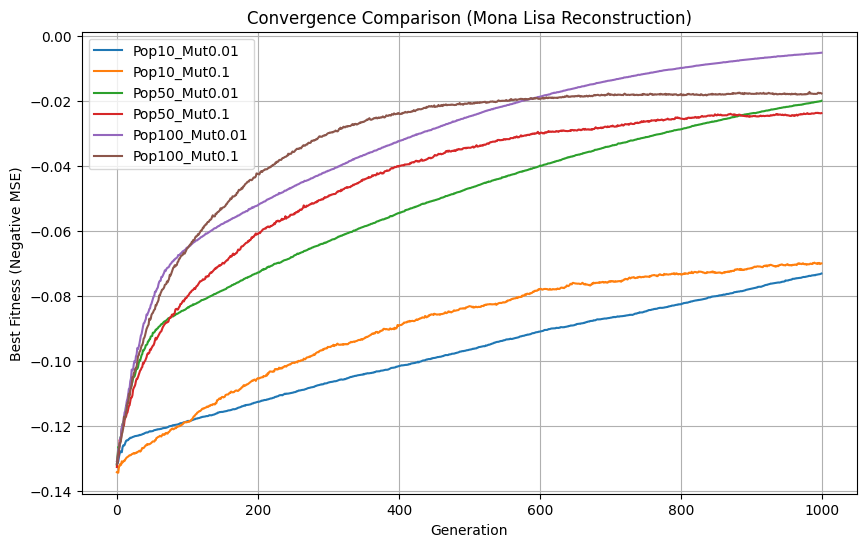

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# Create output directory
if not os.path.exists("/content/images.jfif"):
    os.makedirs("output_images")

def load_target_image(path, size=(64, 64)):
    """Load the target grayscale image."""
    img = Image.open(path).convert('L').resize(size)
    return np.array(img).astype(np.float32) / 255.0

def initialize_population(pop_size, height, width):
    """Create random grayscale images."""
    return np.random.uniform(0, 1, (pop_size, height, width))

def fitness(individual, target):
    """Calculate fitness as negative MSE."""
    return -np.mean((individual - target) ** 2)

def select_parents(population, fitnesses):
    """Pick two parents using tournament selection."""
    idx = np.random.choice(len(population), 3)
    best_idx = idx[np.argmax(fitnesses[idx])]
    idx = np.random.choice(len(population), 3)
    second_idx = idx[np.argmax(fitnesses[idx])]
    return population[best_idx], population[second_idx]

def crossover(parent1, parent2):
    """Blend parents with uniform crossover."""
    mask = np.random.uniform(0, 1, parent1.shape) < 0.5
    return np.where(mask, parent1, parent2)

def mutate(individual, mutation_rate):
    """Add random noise to some pixels."""
    mask = np.random.uniform(0, 1, individual.shape) < mutation_rate
    noise = np.random.normal(0, 0.05, individual.shape)  # Reduced scale for better results
    individual = individual + mask * noise
    return np.clip(individual, 0, 1)

def save_image(image, generation, prefix):
    """Save image as PNG."""
    img_array = (image * 255).astype(np.uint8)
    img = Image.fromarray(img_array, mode='L')
    img.save(f"output_images/{prefix}_gen_{generation:04d}.png")

def run_ga(target_img, pop_size, mutation_rate, generations=1000):
    """Run the genetic algorithm."""
    height, width = target_img.shape
    population = initialize_population(pop_size, height, width)
    best_fitnesses = []

    for gen in range(generations):
        fitnesses = np.array([fitness(ind, target_img) for ind in population])
        best_idx = np.argmax(fitnesses)
        best_fitnesses.append(fitnesses[best_idx])
        save_image(population[best_idx], gen, f"pop{pop_size}_mut{mutation_rate}")

        new_population = []
        for _ in range(pop_size):
            parent1, parent2 = select_parents(population, fitnesses)
            child = crossover(parent1, parent2)
            child = mutate(child, mutation_rate)
            new_population.append(child)
        population = np.array(new_population)

        if gen % 200 == 0:
            print(f"Pop {pop_size}, Mut {mutation_rate}, Gen {gen}, Fitness: {best_fitnesses[-1]:.6f}")

    return best_fitnesses

def main():
    # Load target image
    target_img = load_target_image('/content/images.jfif')

    # Experiment settings
    pop_sizes = [10, 50, 100]
    mutation_rates = [0.01, 0.1]
    generations = 1000  # Increased for better results
    all_fitnesses = {}

    # Run experiments
    for pop_size in pop_sizes:
        for mutation_rate in mutation_rates:
            print(f"\nRunning: Pop Size {pop_size}, Mutation Rate {mutation_rate}")
            key = f"Pop{pop_size}_Mut{mutation_rate}"
            all_fitnesses[key] = run_ga(target_img, pop_size, mutation_rate, generations)

    # Plot fitness comparison
    plt.figure(figsize=(10, 6))
    for key, fitnesses in all_fitnesses.items():
        plt.plot(range(generations), fitnesses, label=key)
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness (Negative MSE)")
    plt.title("Convergence Comparison (Mona Lisa Reconstruction)")
    plt.legend()
    plt.grid(True)
    plt.savefig("output_images/fitness_comparison.png")
    plt.show()

if __name__ == "__main__":
    main()

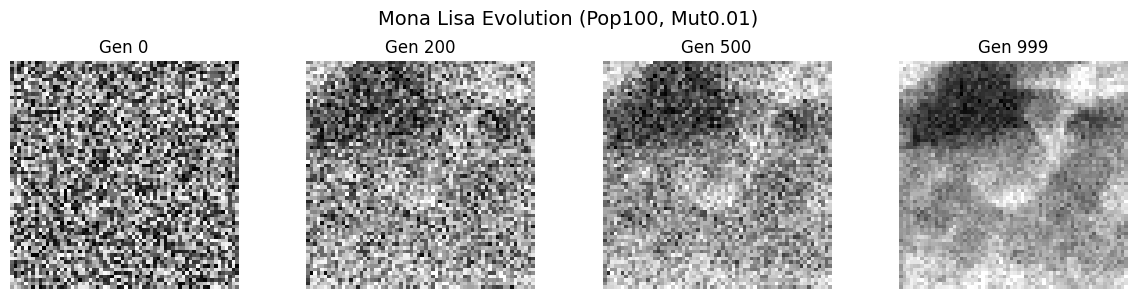

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Settings
prefix = "pop100_mut0.01"  # Best run
generations = [0, 200, 500, 999]  # Key generations (999 since your run goes to 999)
output_dir = "output_images"

# Create a figure with subplots (1 row, 4 columns)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

# Load and display images
for i, gen in enumerate(generations):
    img_path = os.path.join(output_dir, f"{prefix}_gen_{gen:04d}.png")
    if os.path.exists(img_path):
        img = Image.open(img_path)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Gen {gen}")
        axes[i].axis('off')
    else:
        print(f"Image not found: {img_path}")

# Add a title and save the plot
plt.suptitle(f"Mona Lisa Evolution (Pop100, Mut0.01)", fontsize=14)
plt.tight_layout()
plt.savefig("output_images/pop100_mut0.01_evolution_fix.png")
plt.show()